# Анализ критериев найма сотрудников в торговых сетях **Gotham City**

## Задача
Проанализировать базу данных работников организаций и выявить закономерности в подборе персонала для трех торговых сетей:
- **Super Store** - Премиальный сегмент
- **DCU** - средний сегмент
- **Joker Hub** - дискаунтер

## Данные
База данных содержит 500 записей жителей города и имеет следующие поля:
`id`, `first_name`, `last_name`, `store`, `date_of_birth`,
`education`, `retail_experience`, `languages`

## Допущения

- Пол сотрудников в данных явно не указан — определен автоматически по окончанию имени (а/я → женский, иначе → мужской)
- Возраст рассчитан на дату проведения анализа
- Поле `languages` содержит перечисление через запятую — для анализа данные были развернуты в отдельные строки

In [25]:
# Импортируем библиотеки
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Подключаемся к БД и загружаем все данные
conn = sqlite3.connect('gotham_city.db')

def query(sql):
    return pd.read_sql(sql, conn)

# Загружаем все данные
df = query("SELECT * FROM residents")

Добавим необходимые поля для анализа

In [29]:
# Определяем пол по имени
def get_gender(name):
    name = name.strip().lower()
    if name.endswith(('а', 'я')):
        return 'female'
    else:
        return 'male'

df['gender'] = df['first_name'].apply(get_gender)

# Считаем возраст по дате рождения на Сегодняшний день
df['age'] = (pd.Timestamp.now() - pd.to_datetime(df['date_of_birth'])).dt.days // 365

df.head()

,id,first_name,last_name,store,date_of_birth,education,retail_experience,languages,gender,age
0,1,Катя,Иваченко,Super Store,1996-03-28,Высшее,Нет,Английский,female,29
1,2,Надежда,Иваченко,Super Store,1995-03-29,Высшее,Да,"Английский, Испанский",female,30
2,3,Алиса,Живаго,Super Store,1990-03-30,Неоконченное среднее,Да,"Русский, Испанский, Английский",female,35
3,4,Ева,Седых,Super Store,1989-03-30,Cреднее,Нет,"Русский, Английский, Испанский",female,36
4,5,Надежда,Седых,Super Store,1991-03-30,Неоконченное среднее,Нет,"Русский, Испанский",female,34


## Анализ признаков

Для каждого признака проверяем — есть ли различия между магазинами.
Если распределение значимо отличается — признак является критерием отбора.

### 1. Пол

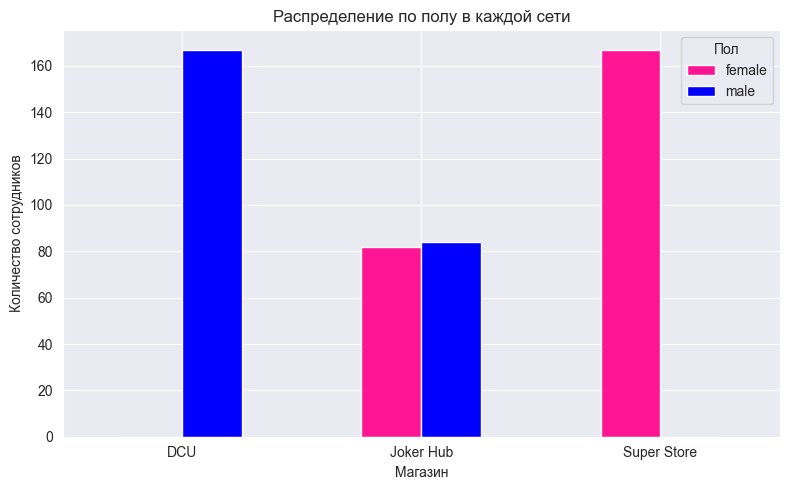

In [46]:
gender_dist = df.groupby(['store', 'gender']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(8, 5))
stores = df['store'].unique()
colors = {'female': '#FF1493', 'male': 'blue'}

gender_pivot = gender_dist.pivot(index='store', columns='gender', values='count').fillna(0)
gender_pivot.plot(kind='bar', ax=ax, color=[colors.get(c) for c in gender_pivot.columns])

ax.set_title('Распределение по полу в каждой сети')
ax.set_xlabel('Магазин')
ax.set_ylabel('Количество сотрудников')
ax.legend(title='Пол')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:**
В премиальном сегменте (Super Store) работают исключительно женщины,
в среднем (DCU) — исключительно мужчины, в дискаунтере (Joker Hub)
пол не является критерием отбора — распределение равномерное.

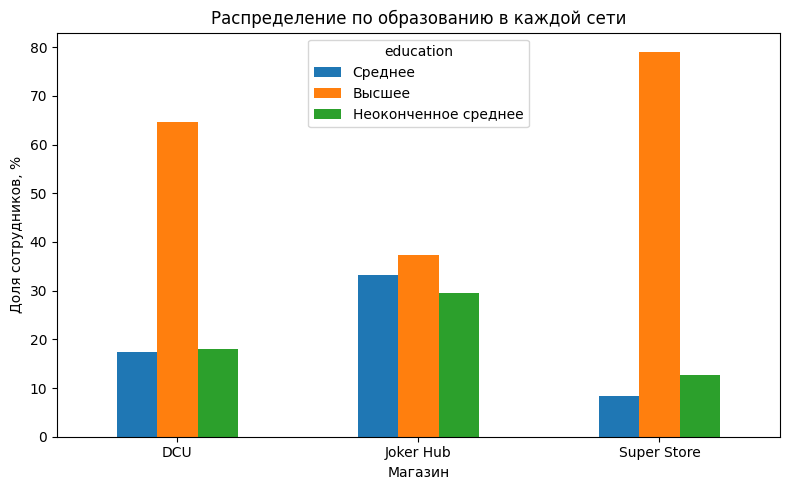

In [33]:
edu_dist = df.groupby(['store', 'education']).size().reset_index(name='count')
edu_pivot = edu_dist.pivot(index='store', columns='education', values='count').fillna(0)

edu_pct = edu_pivot.div(edu_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
edu_pct.plot(kind='bar', ax=ax)
ax.set_title('Распределение по образованию в каждой сети')
ax.set_xlabel('Магазин')
ax.set_ylabel('Доля сотрудников, %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:**
Прослеживается четкая зависимость между сегментом сети и требованиями
к образованию. В Super Store 80% сотрудников имеют высшее образование,
в DCU — 65%, тогда как в Joker Hub распределение равномерное —
около 33% на каждый уровень.
Чем выше ценовой сегмент, тем выше требования к образованию.

### 3. Возраст

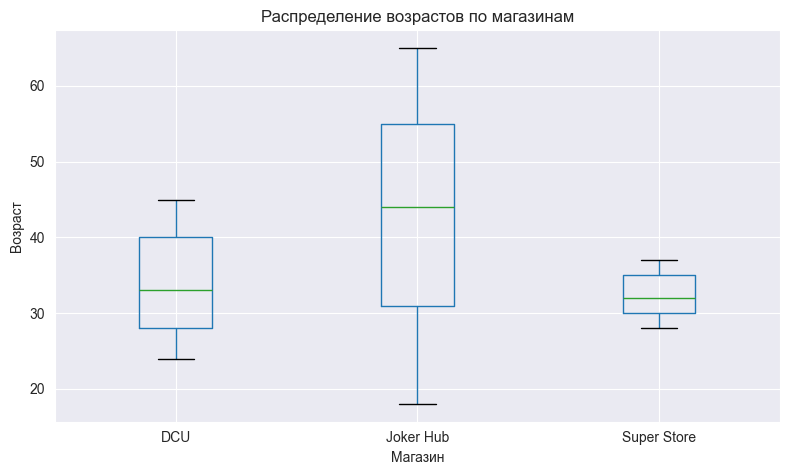

,min,max,mean,median,std
store,,,,,
DCU,24,45,33.7,33.0,6.5
Joker Hub,18,65,42.7,44.0,14.0
Super Store,28,37,32.3,32.0,2.8


In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='age', by='store', ax=ax)
ax.set_title('Распределение возрастов по магазинам')
plt.suptitle('')
ax.set_xlabel('Магазин')
ax.set_ylabel('Возраст')
plt.tight_layout()
plt.show()

# Статистика
df.groupby('store')['age'].agg(['min', 'max', 'mean', 'median', 'std']).round(1)

**Вывод:**
Прослеживается чёткая зависимость между ценовым сегментом и возрастным
разбросом сотрудников. В Super Store возраст сотрудников сконцентрирован
в узком диапазоне (std = 2.8), в DCU разброс заметно шире (std = 6.5),
а в Joker Hub возраст практически не является критерием отбора (std = 14).

Чем выше ценовой сегмент — тем строже возрастные требования.

### 4. Опыт в ритейле

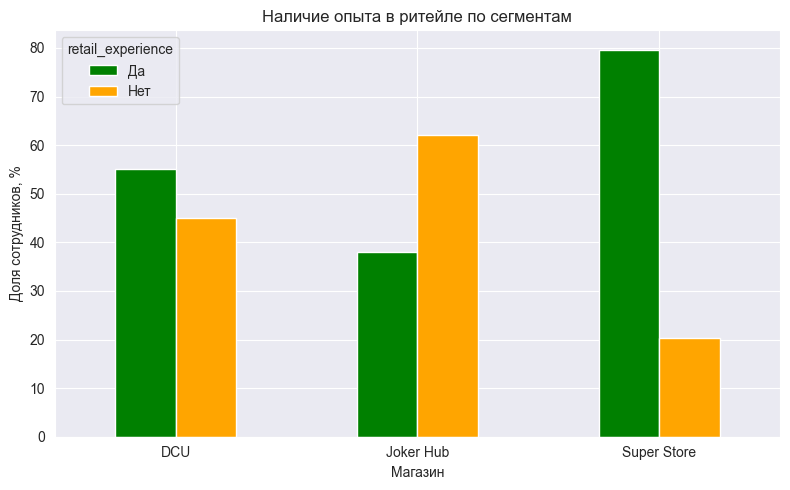

store        retail_experience
DCU          Да                   55.1
             Нет                  44.9
Joker Hub    Нет                  62.0
             Да                   38.0
Super Store  Да                   79.6
             Нет                  20.4
Name: proportion, dtype: float64

In [37]:
exp_dist = df.groupby(['store', 'retail_experience']).size().reset_index(name='count')
exp_pivot = exp_dist.pivot(index='store', columns='retail_experience', values='count').fillna(0)

# Считаем доли
exp_pct = exp_pivot.div(exp_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
exp_pct.plot(kind='bar', ax=ax, color=['green', 'orange'])
ax.set_title('Наличие опыта в ритейле по сегментам')
ax.set_xlabel('Магазин')
ax.set_ylabel('Доля сотрудников, %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df.groupby('store')['retail_experience'].value_counts(normalize=True).mul(100).round(1)

**Вывод:**
В опыте работы, так же прослеживается зависимость с ценовым сегментом. Super Store Делает уклон в "Опытных" сотрудников (80%), DCU - держит баланс между "Опытными" и "Не опытными сотрудниками" (45%-55%), Joker Hub - экономит на "Опытных" сотрудниках (38%).

Чем ниже ценовой сегмент, тем больше набирают не опытных сотрудников.

### 5. Языки

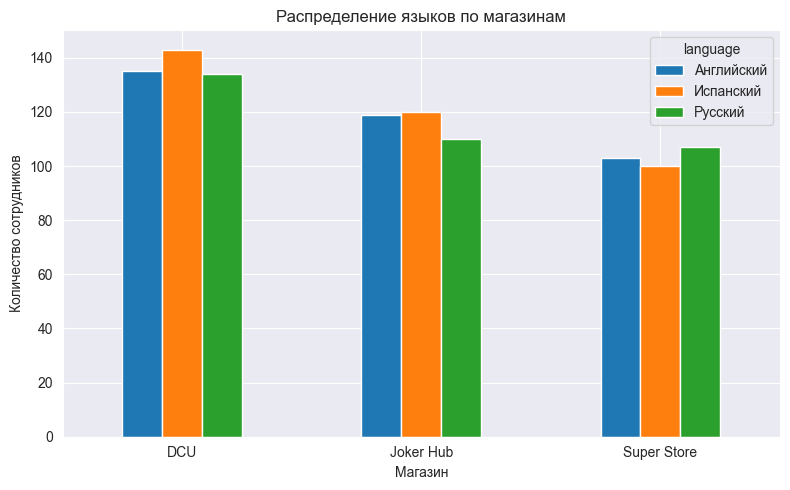

In [38]:
lang_exploded = df.assign(
    language=df['languages'].str.split(',')
).explode('language')
lang_exploded['language'] = lang_exploded['language'].str.strip()

lang_dist = lang_exploded.groupby(['store', 'language']).size().reset_index(name='count')
lang_pivot = lang_dist.pivot(index='store', columns='language', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
lang_pivot.plot(kind='bar', ax=ax)
ax.set_title('Распределение языков по магазинам')
ax.set_xlabel('Магазин')
ax.set_ylabel('Количество сотрудников')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:**
Зависимости между знанием языков и ценовым сегментом сети не обнаружено.
Распределение языков равномерно для всех трех сетей.

Возможное объяснение: критерием может являться не количество языков,
а уровень владения — однако эти данные в базе отсутствуют.

## Итоговые выводы

### Портрет типичного сотрудника

**Super Store (премиум):**
Женщина, 30-35 лет, с высшим образованием и опытом работы в ритейле.

**DCU (средний сегмент):**
Мужчина, 27-40 лет, преимущественно с высшим образованием,
опыт работы не обязателен.

**Joker Hub (дискаунтер):**
Без ограничений по полу, 28-56 лет, образование любое,
опыт работы не требуется.

### Значимые критерии отбора

| Признак | Super Store    | DCU            | Joker Hub       |
|---|----------------|----------------|-----------------|
| Пол | Только женщины | Только мужчины | Без ограничений |
| Образование | 80% высшее     | 60% высшее     | Равномерно      |
| Возраст | 30-35    | 27-40    | 28-56           |
| Опыт в ритейле | 80% с опытом   | 55% с опытом   | 38% с опытом    |